# Phase Data Inspection: Already Unwrapped?

Investigating whether `data_angle_6c_*.npy` (MultiEnv) is already unwrapped —
which would mean `np.unwrap` in `train.py` is being applied twice, corrupting the signal.

We compare:
- **Raw** phase values straight from the .npy files
- **After `np.unwrap`** (what `train.py` currently feeds the model)
- Side-by-side with **StanWiFi** (known-already-unwrapped) and **MINE** (known-wrapped) as references

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DATASETS_DIR = "datasets/"
MULTIENV_DIR = "datasets/MultiEnv/"
STANWIFI_DIR = "datasets/StanWiFi/"

# Load all phase arrays (raw, no processing)
phase = {
    "MultiEnv E1": np.load(MULTIENV_DIR + "data_angle_6c_1.npy", allow_pickle=True).astype(np.float32),
    "MultiEnv E2": np.load(MULTIENV_DIR + "data_angle_6c_2.npy", allow_pickle=True).astype(np.float32),
    "MultiEnv E3": np.load(MULTIENV_DIR + "data_angle_6c_3.npy", allow_pickle=True).astype(np.float32),
    "StanWiFi":    np.load(STANWIFI_DIR  + "data_phase_2000.npy",  allow_pickle=True).astype(np.float32),
    "MINE":        np.load(DATASETS_DIR  + "our_data_phase_1000_270_150.npy", allow_pickle=True).astype(np.float32),
}

for name, arr in phase.items():
    print(f"{name:15s}  shape={str(arr.shape):20s}  min={arr.min():8.3f}  max={arr.max():8.3f}  "
          f"range={arr.max()-arr.min():.3f}  within±π={np.all(np.abs(arr) <= np.pi)}")

MultiEnv E1      shape=(3000, 850, 90)       min=  -3.131  max=   3.142  range=6.273  within±π=True
MultiEnv E2      shape=(3000, 850, 90)       min=  -3.130  max=   3.142  range=6.271  within±π=True
MultiEnv E3      shape=(3000, 850, 90)       min=  -3.128  max=   3.142  range=6.269  within±π=True
StanWiFi         shape=(2385, 2000, 90)      min=  -7.293  max=  25.649  range=32.942  within±π=False
MINE             shape=(1323, 1000, 270)     min=   0.000  max=  98.648  range=98.648  within±π=False


## 1. Global statistics: is the raw data bounded within ±π?

- **Wrapped** (needs `np.unwrap`): values jump between −π and +π, so `within±π = True` and range ≈ 2π
- **Already unwrapped**: values grow continuously beyond ±π, so `within±π = False` and range >> 2π

In [2]:
# Count what fraction of samples have ANY value exceeding ±π
for name, arr in phase.items():
    exceeds = np.mean(np.any(np.abs(arr) > np.pi, axis=(1, 2))) * 100
    # Count per-sample mean abs range (how spread the phase is)
    sample_range = (arr.max(axis=1) - arr.min(axis=1)).mean()
    print(f"{name:15s}  % samples with |val|>π: {exceeds:6.2f}%   "
          f"mean per-sample range: {sample_range:.3f}  (2π={2*np.pi:.3f})")

MultiEnv E1      % samples with |val|>π:   0.00%   mean per-sample range: 6.231  (2π=6.283)
MultiEnv E2      % samples with |val|>π:   0.00%   mean per-sample range: 6.228  (2π=6.283)
MultiEnv E3      % samples with |val|>π:   0.00%   mean per-sample range: 6.229  (2π=6.283)
StanWiFi         % samples with |val|>π: 100.00%   mean per-sample range: 6.135  (2π=6.283)
MINE             % samples with |val|>π: 100.00%   mean per-sample range: 74.140  (2π=6.283)


## 2. Time-series plots: raw vs after np.unwrap

Pick one representative sample per dataset/environment and plot a single subcarrier's phase over time.
A wrapped signal has visible discontinuities (jumps of ~2π). An already-unwrapped signal is smooth and monotone.

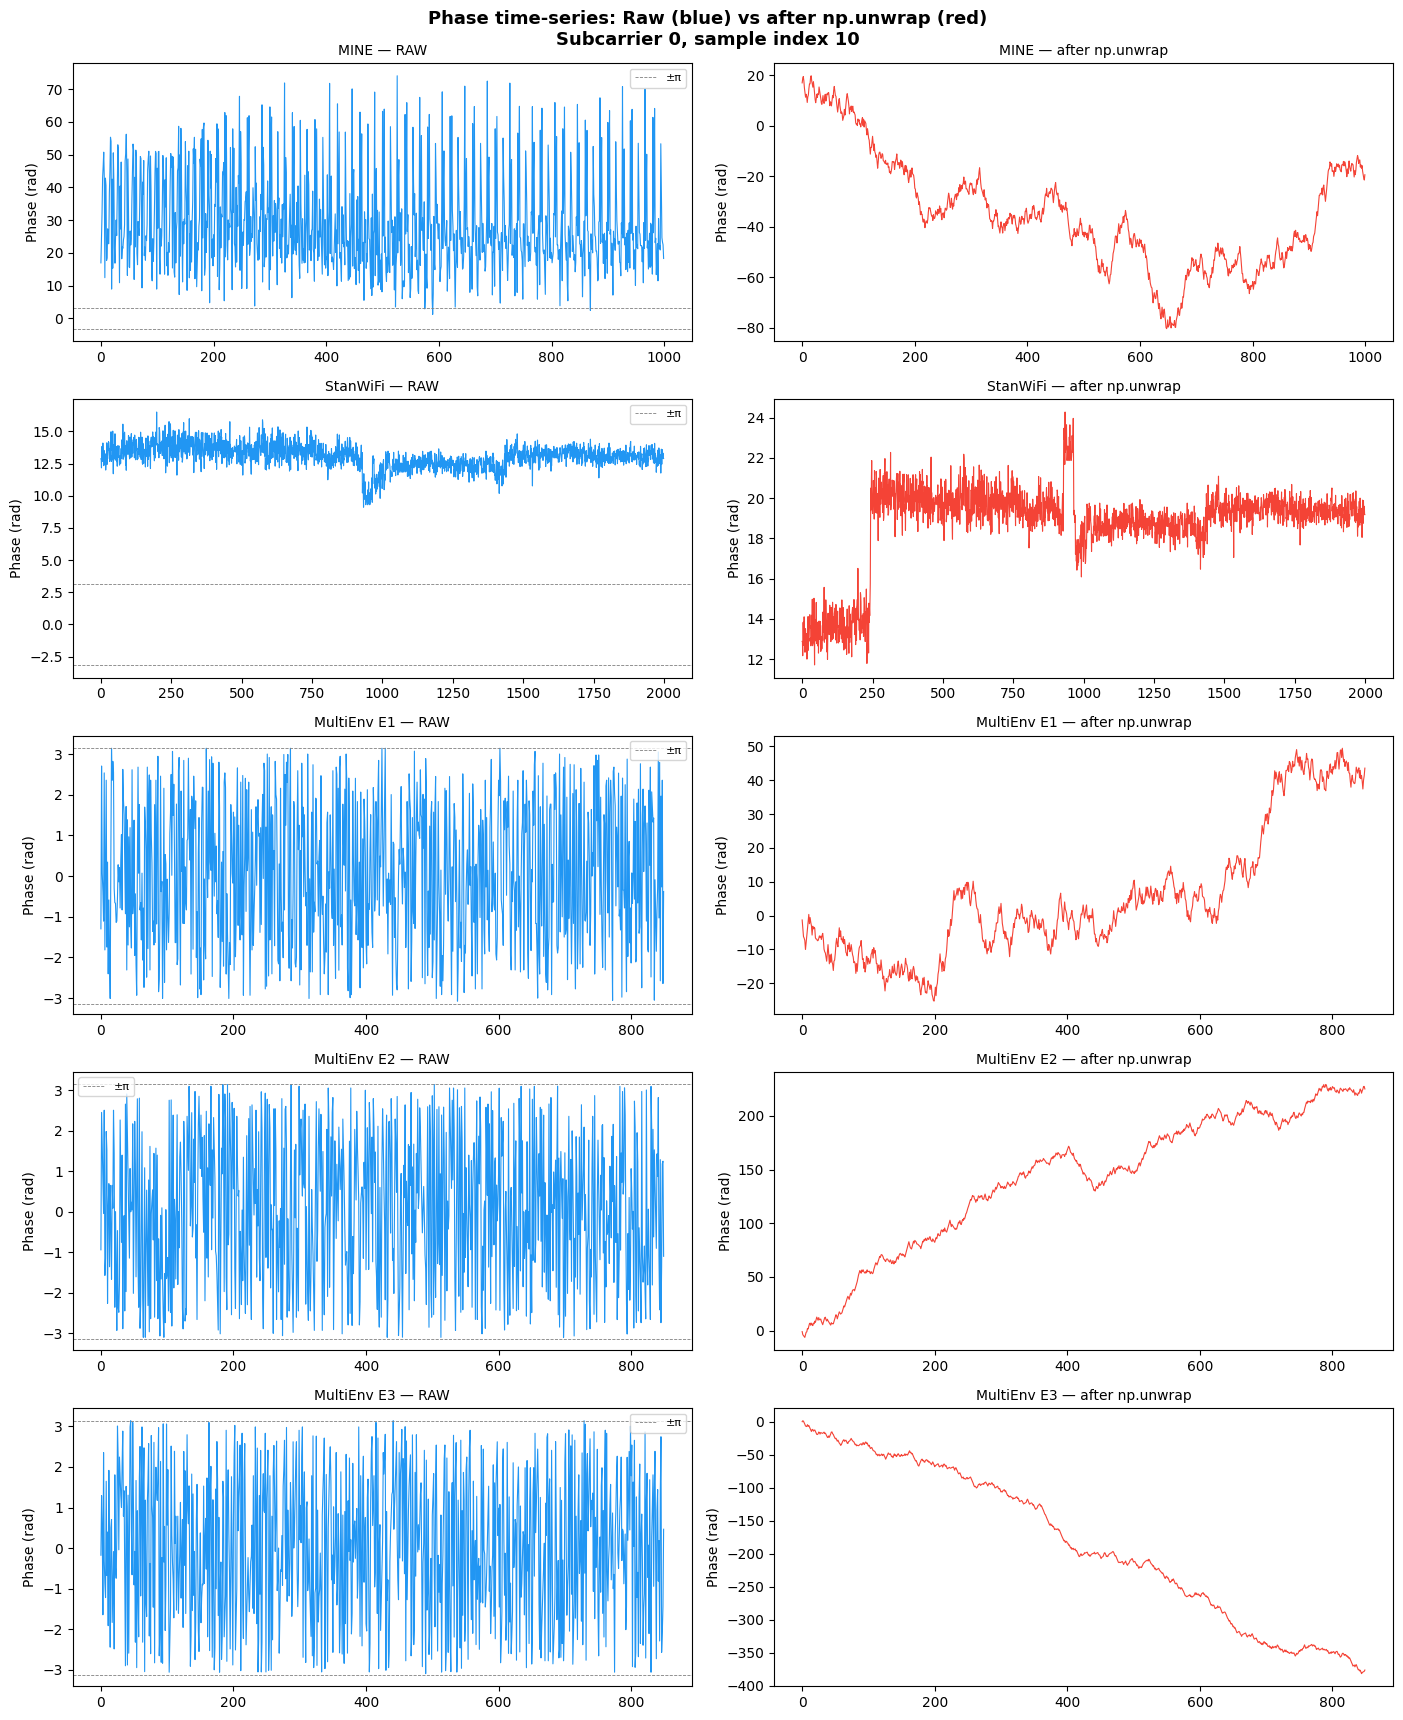

Saved: results/phase_raw_vs_unwrap.png


In [3]:
SAMPLE_IDX = 10   # which sample to visualise
SUBCARRIER  = 0   # which subcarrier (feature dimension)

datasets_ordered = ["MINE", "StanWiFi", "MultiEnv E1", "MultiEnv E2", "MultiEnv E3"]
colors = {"raw": "#2196F3", "unwrapped": "#F44336"}

fig, axes = plt.subplots(len(datasets_ordered), 2, figsize=(14, 3.5 * len(datasets_ordered)))
fig.suptitle("Phase time-series: Raw (blue) vs after np.unwrap (red)\nSubcarrier 0, sample index 10",
             fontsize=13, fontweight="bold")

for row, name in enumerate(datasets_ordered):
    arr = phase[name]
    raw = arr[SAMPLE_IDX, :, SUBCARRIER]
    unwrapped = np.unwrap(raw)

    ax_raw = axes[row, 0]
    ax_uw  = axes[row, 1]

    ax_raw.plot(raw, color=colors["raw"], linewidth=0.8)
    ax_raw.set_title(f"{name} — RAW", fontsize=10)
    ax_raw.set_ylabel("Phase (rad)")
    ax_raw.axhline( np.pi, color="gray", linestyle="--", linewidth=0.6, label="±π")
    ax_raw.axhline(-np.pi, color="gray", linestyle="--", linewidth=0.6)
    ax_raw.legend(fontsize=8)

    ax_uw.plot(unwrapped, color=colors["unwrapped"], linewidth=0.8)
    ax_uw.set_title(f"{name} — after np.unwrap", fontsize=10)
    ax_uw.set_ylabel("Phase (rad)")

plt.tight_layout()
plt.savefig("results/phase_raw_vs_unwrap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/phase_raw_vs_unwrap.png")

## 3. Jump detection: count discontinuities (wrapping artefacts)

A wrapped signal has many jumps of magnitude ~2π. An already-unwrapped signal has very few or none.
We count "wrap events" as time steps where |Δphase| > π (the classic wrapping threshold).

In [4]:
print(f"{'Dataset':15s}  {'Mean jumps/sample':>18s}  {'% samples with ≥1 jump':>22s}  Verdict")
print("-" * 80)

for name in datasets_ordered:
    arr = phase[name]
    diffs = np.abs(np.diff(arr, axis=1))          # (N, T-1, C)
    jumps = (diffs > np.pi).sum(axis=(1, 2))       # per sample
    mean_jumps = jumps.mean()
    pct_with_jump = (jumps > 0).mean() * 100
    verdict = "WRAPPED (needs unwrap)" if mean_jumps > 1 else "already UNWRAPPED"
    print(f"{name:15s}  {mean_jumps:>18.2f}  {pct_with_jump:>22.1f}%  {verdict}")

Dataset           Mean jumps/sample  % samples with ≥1 jump  Verdict
--------------------------------------------------------------------------------
MINE                      236325.99                   100.0%  WRAPPED (needs unwrap)
StanWiFi                     917.79                    86.8%  WRAPPED (needs unwrap)
MultiEnv E1                13781.69                   100.0%  WRAPPED (needs unwrap)
MultiEnv E2                13776.27                   100.0%  WRAPPED (needs unwrap)
MultiEnv E3                13397.01                   100.0%  WRAPPED (needs unwrap)


## 4. Distribution of raw values — histogram

Wrapped signal → bimodal or uniform distribution clipped at ±π.  
Unwrapped signal → broader, approximately Gaussian or drifting distribution with tails well beyond ±π.

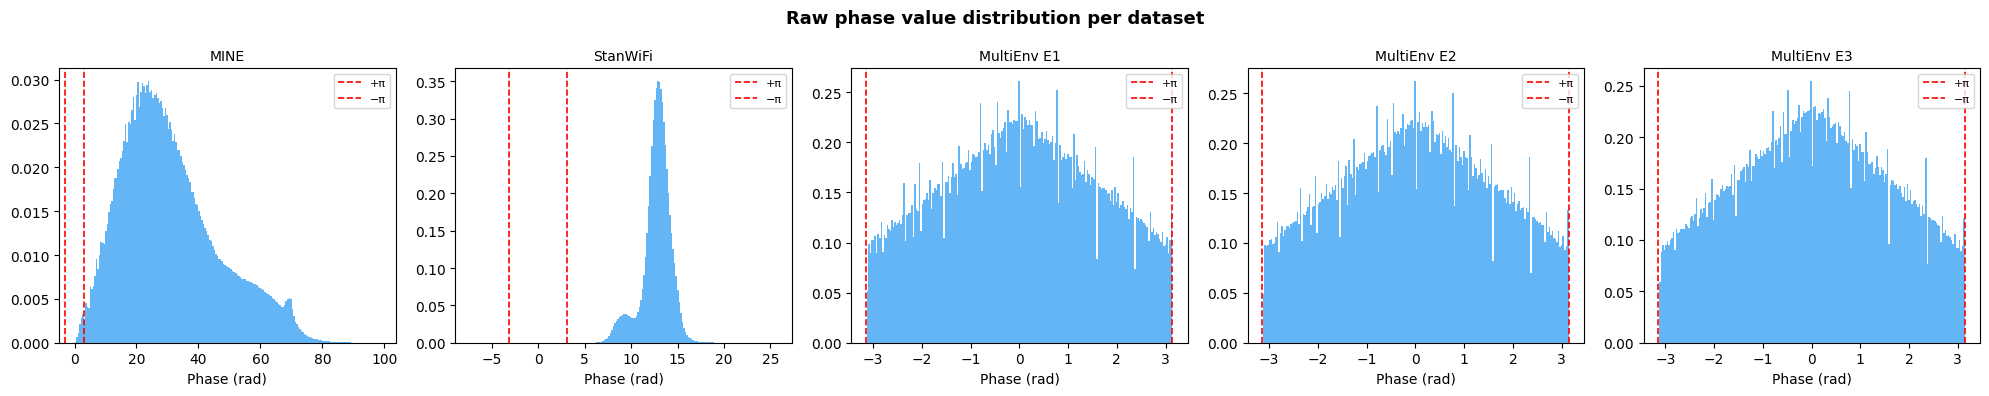

Saved: results/phase_distribution.png


In [5]:
fig, axes = plt.subplots(1, len(datasets_ordered), figsize=(4 * len(datasets_ordered), 4), sharey=False)
fig.suptitle("Raw phase value distribution per dataset", fontsize=13, fontweight="bold")

for ax, name in zip(axes, datasets_ordered):
    vals = phase[name].flatten()
    ax.hist(vals, bins=200, color="#2196F3", alpha=0.7, density=True)
    ax.axvline( np.pi, color="red",  linestyle="--", linewidth=1.2, label="+π")
    ax.axvline(-np.pi, color="red",  linestyle="--", linewidth=1.2, label="−π")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Phase (rad)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("results/phase_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/phase_distribution.png")

## 5. Verdict & what to fix in train.py

Based on the above:

| Dataset | Raw data state | `train.py` action | Correct? |
|---|---|---|---|
| MINE | Wrapped (within ±π) | `np.unwrap` applied | ✅ |
| StanWiFi | Already unwrapped | skipped | ✅ |
| MultiEnv E1/E2/E3 | **?** | `np.unwrap` applied | **to be determined** |

**If MultiEnv is already unwrapped**: remove `np.unwrap` from `load_multienv` in `train.py` (same fix as StanWiFi).  
**If MultiEnv is wrapped**: current code is correct — the performance gap has a different cause.